## Améliorez le modèle


### Reconnaissez un modèle qui sous-performe

Le calcul du score sur les données d'entraînement et de test vont nous permettre de distinguer un bon modèle d'un mauvais modèle.

On a distingue : 

1. Le modèle ne comprend rien aux données.
Son  score(train)  est faible  donc le  score(test)  sera faible. On parle dans ce cas de biais du modèle.

2. Le modèle est bon et sait généraliser.
Les  score(train)  et  score(test)  sont satisfaisants.

3. Le modèle ne sait pas généraliser.
Le  score(train)  est bon mais le  score(test)  est faible. On appelle cela l'overfit, le sur-apprentissage.

**note** : Il existe encore un dernier cas : bon score(test) mais mauvais score(train). Il reflète la plupart du temps une anomalie statistique et arrive très rarement. On ne le prend pas en compte.


`L'optimisation du modèle par le jeu de ses paramètres consiste à trouver le juste milieu entre le biais et l'overfit.`


## Pratique 
Nous allons construire un modèle qui prédit le stade de développement de l'arbre.

Un cas de classification a 4 catégories que nous avons déjà vues :

1. Jeune (arbre) 

2. Jeune (arbre)Adulte 

3. Adulte

4. Mature

Dans le dataset, ces catégories sont numérisées en 1, 2, 3 et 4.

En ce qui concerne le modèle, nous allons utiliser un arbre de décision comme classificateur. En l'occurence, le modèle DecisionTreeClassifier de scikit-learn.

Nous avons choisi un arbre de décision simplement parce que ce type de modèle se prête parfaitement à la démonstration d'overfitting et de biais. Les modèles linéaires de régression sont incapables d'overfitter autrement que sur des jeux de données de démonstrations, et le k-means serait peu réaliste dans notre contexte.




## Comprenez la notion d’arbre de décision

Un arbre de décision est un enchaînement de règles de classification établies automatiquement à partir des variables prédictrices.

Les décisions sont appelées `noeuds` et les liens entre les noeuds sont appelés `branches`.

Dans la documentation scikit-learn  , on a les hyper paramètres (paramètres qui modifient le comportement d'un modèle) : 

- **criterion** : la fonction qui mesure la qualité d'une bifurcation en 2 branches.

- **max_depth** :  qui règle le pruning (la profondeur de l'arbre)

C'est avec ce paramètre que nous allons maintenant jouer pour montrer le biais et l'overfit du modèle.

## Minimisez le biais du modèle

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# chargement des données

filename = 'https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/paris-arbres-numerical-2023-09-10.csv'
data = pd.read_csv(filename)

# X la matrice des prédicteurs
X = data[['domanialite', 'arrondissement', 'libelle_francais', 'genre', 'espece', 'circonference_cm', 'hauteur_m']]

# y la matrice de la variable cible
y = data.stade_de_developpement.values

In [3]:
# separation des données en train et en test
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=808)

In [4]:
from sklearn.tree import DecisionTreeClassifier

clf=DecisionTreeClassifier(max_depth=3,random_state=808)
clf.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",808
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [5]:
# pour le score , utilisons AUC
from sklearn.metrics import roc_auc_score

y_train_pred = clf.predict_proba(X_train)
y_test_pred = clf.predict_proba(X_test)

train_auc = roc_auc_score(y_train,y_train_pred,multi_class='ovr')
test_auc = roc_auc_score(y_test, y_test_pred, multi_class="ovr")

print(f"train : {train_auc:.2%}")
print(f"test : {test_auc:.2%}")

train : 88.77%
test : 88.82%


In [6]:
# matrice de confusion
from sklearn.metrics import confusion_matrix

y_train_hat = clf.predict(X_test)
y_test_hat = clf.predict(X_test)

print(confusion_matrix(y_test, y_test_hat))

[[ 5570  1402   300     2]
 [ 1060  3847  2750     8]
 [  211  1481 13328   466]
 [    4     7   565   877]]


In [8]:
# maintenant le rapport de classification
from sklearn.metrics import classification_report

print(classification_report(y_test,y_test_hat))

              precision    recall  f1-score   support

           1       0.81      0.77      0.79      7274
           2       0.57      0.50      0.53      7665
           3       0.79      0.86      0.82     15486
           4       0.65      0.60      0.63      1453

    accuracy                           0.74     31878
   macro avg       0.70      0.68      0.69     31878
weighted avg       0.73      0.74      0.74     31878



On voit que la  precision est faible pour les catégories  Jeune (arbre)Adulte  et  Mature  (respectivement 0,57 et 0,67) et nous observons un recall de 0,5 pour la catégorie  Jeune (arbre)  aussi très faible.

**C'est un bon exemple d'un modèle biaisé.**

In [7]:
print(f" train : {clf.score(X_train,y_train):.3%}")
print(f" test : {clf.score(X_test,y_test):.3%}")

 train : 74.099%
 test : 74.101%


Le score(test) et le score(train) sont presque égaux.

Plusieurs stratégies pour minimiser le biais du modèle :

- Ajouter des données 

-  soit utiliser des techniques d'augmentation de données qui créent des échantillons artificiels et gonflent donc artificiellement le dataset d'entraînement.

- Le fameux feature engineering où l'on va s'efforcer de transformer ou d'ajouter des variables pour encoder plus d'informations exploitables par le modèle.

- Modifier les paramètres du modèle pour améliorer sa performance. 

## Identifiez et compensez l'overfit

Reprenons l'arbre de décision sans limiter la profondeur


In [8]:
clf = DecisionTreeClassifier(max_depth=None,random_state=808)

clf.fit(X_train,y_train)
print(f" train : {clf.score(X_train,y_train):.3%}")
print(f" test : {clf.score(X_test,y_test):.3%}")

 train : 93.546%
 test : 80.601%


On remarque que le score d'entrainement est largement superieur au score de test , nous sommes bien dans un cas d'overfitting . 
On va realiser la courbe du score de train et du score de test en fonction du max_depth.

In [11]:
scores = []

for depth in np.arange(2, 30, 3):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=808)
    clf.fit(X_train, y_train)
    train_auc = roc_auc_score(y_train, clf.predict_proba(X_train), multi_class="ovr")
    test_auc = roc_auc_score(y_test, clf.predict_proba(X_test), multi_class="ovr")

    scores.append({"max_depth": depth, "train": train_auc, "test": test_auc})

scores = pd.DataFrame(scores)
scores.head()

,max_depth,train,test
0,2,0.847089,0.848144
1,5,0.914770,0.914735
2,8,0.935176,0.932428
3,11,0.952259,0.937008
4,14,0.969425,0.927180


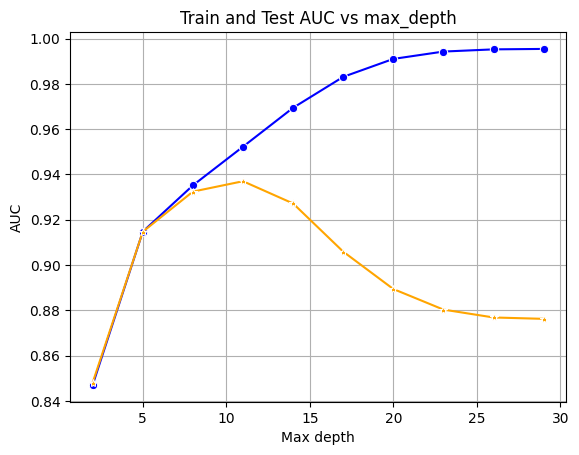

In [16]:
sns.lineplot(data=scores,x='max_depth',y='train',c='blue',marker='o')
sns.lineplot(data=scores, x="max_depth", y="test", c="orange", marker="*")
plt.grid(visible=True)
plt.title('Train and Test AUC vs max_depth')
plt.xlabel('Max depth')
plt.ylabel('AUC')
plt.show()

Quand on augmente  max_depth  , l'AUC(train) croît jusqu'à presque atteindre un score parfait de 1. Ce score atteint ensuite un plateau. Augmenter la profondeur de l'arbre ne sert plus à rien à partir de max_depth = 20 .

L'AUC(test) par contre, croît jusqu'à atteindre un maximum autour de  0.94  (  max_depth = 9  ). Elle décroît ensuite jusqu'à  0.87  pour rejoindre elle aussi un plateau vers  max_depth = 20  .

On observe bien les 3 cas de comportement du modèle :

à gauche, le modèle sous-performe (biais) ;

à droite, il overfit ;

au milieu, on obtient la meilleure performance sur le test set.

On a ainsi trouvé la valeur optimale du paramètre  max_depth  pour ce modèle et ce dataset donnés, soit  9  ou  10  .